In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# Task 1: Insurance Charges Prediction

In [7]:
# Load dataset
insurance = pd.read_csv('insurance.csv')
print("\n--- Insurance Dataset Head ---")
print(insurance.head())


--- Insurance Dataset Head ---
   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


In [8]:
# Basic info
print("\n--- Dataset Info ---")
print(insurance.info())
print("\n--- Summary Stats ---")
print(insurance.describe())


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       348 non-null    int64  
 1   sex       348 non-null    int64  
 2   bmi       348 non-null    float64
 3   children  348 non-null    int64  
 4   smoker    348 non-null    int64  
 5   region    348 non-null    int64  
 6   charges   348 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 19.2 KB
None

--- Summary Stats ---
              age         sex         bmi    children      smoker      region  \
count  348.000000  348.000000  348.000000  348.000000  348.000000  348.000000   
mean    39.591954    0.508621   30.676552    1.091954    0.232759    1.497126   
std     14.417015    0.500646    5.625850    1.192021    0.423198    1.104089   
min     18.000000    0.000000   15.960000    0.000000    0.000000    0.000000   
25%     27.000000    0.000000   26.7825

In [9]:
# Check null values
print("\n--- Null Values ---")
print(insurance.isnull().sum())


--- Null Values ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
# Encode categorical features
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    insurance[col] = le.fit_transform(insurance[col])

In [12]:
# Independent & dependent variables
X = insurance.drop('charges', axis=1)
y = insurance['charges']

In [13]:
# Normalize numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [15]:
# Train model
regressor = LinearRegression()
regressor.fit(X_train, y_train)


print("\n--- Model Coefficients ---")
print("Intercept:", regressor.intercept_)
print("Coefficients:", regressor.coef_)


--- Model Coefficients ---
Intercept: 13832.203379392202
Coefficients: [3812.24215641  -21.42696015 2066.39789041  727.20265898 9815.68757869
 -322.79084906]


In [16]:
# Predictions
y_pred = regressor.predict(X_test)

In [17]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\n--- Model Evaluation ---")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


--- Model Evaluation ---
MSE: 37726891.070389286
RMSE: 6142.221997810669
R2: 0.7918111887183532


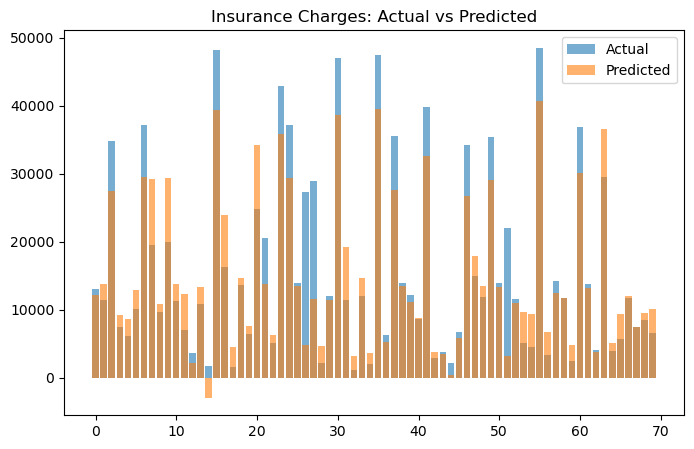

In [18]:
# Visualization: Actual vs Predicted
plt.figure(figsize=(8,5))
plt.bar(range(len(y_test)), y_test.values, alpha=0.6, label="Actual")
plt.bar(range(len(y_pred)), y_pred, alpha=0.6, label="Predicted")
plt.title("Insurance Charges: Actual vs Predicted")
plt.legend()
plt.show()

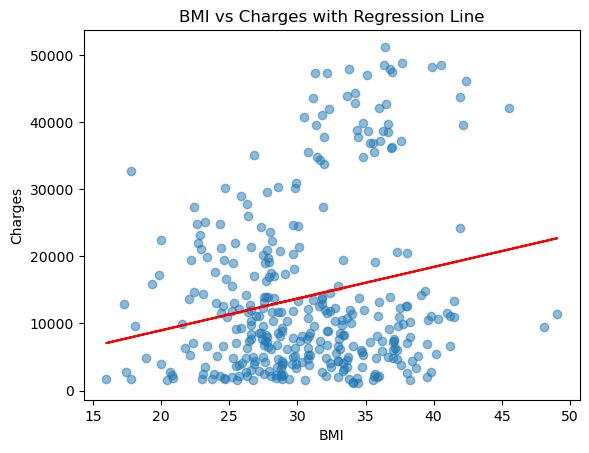

In [39]:
# Regression line for one feature (BMI vs Charges)
plt.scatter(insurance['bmi'], insurance['charges'], alpha=0.5)
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Charges with Regression Line")
bmi = insurance[['bmi']]
charges = insurance['charges']
model_bmi = LinearRegression()
model_bmi.fit(bmi, charges)
plt.plot(bmi, model_bmi.predict(bmi), color='red')
plt.show()

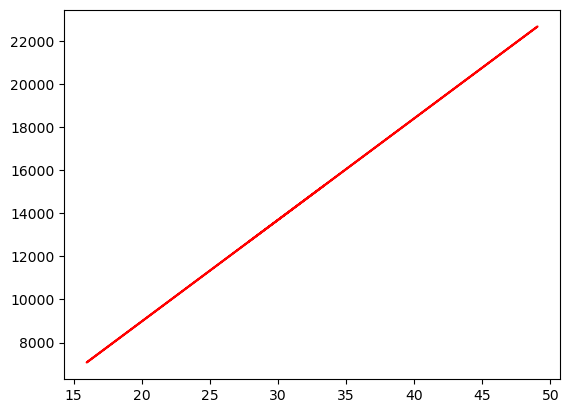

In [26]:
# Manual Gradient Descent for BMI feature
X_bmi = insurance['bmi'].values
Y_charges = insurance['charges'].values


def gradient_descent(x, y, lr=0.0001, epochs=1000):
    n = len(x)
    m, b = 0, 0
    for _ in range(epochs):
        y_pred = m*x + b
        error = y - y_pred
        m_grad = -(2/n) * sum(x * error)
        b_grad = -(2/n) * sum(error)
        m -= lr * m_grad
        b -= lr * b_grad
    return m, b


m, b = gradient_descent(X_bmi, Y_charges)
print("\n--- Gradient Descent (BMI) ---")
print(f"Slope: {m}, Intercept: {b}")


--- Gradient Descent (BMI) ---
Slope: 457.03785037562477, Intercept: 11.349071669350925


In [27]:
# Task 2: Salary Prediction

In [29]:
# Load dataset
salary = pd.read_csv('Salary_dataset.csv')
print("\n--- Salary Dataset Head ---")
print(salary.head())


--- Salary Dataset Head ---
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0


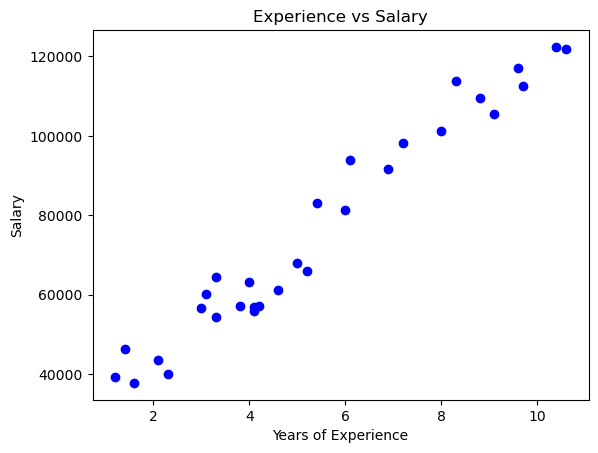

In [30]:
# Scatter plot
plt.scatter(salary['YearsExperience'], salary['Salary'], color='blue')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

In [31]:
# Train-test split
X = salary[['YearsExperience']]
y = salary['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# Linear Regression
regressor = LinearRegression()
regressor.fit(X_train, y_train)


print("\n--- Salary Model ---")
print("Intercept:", regressor.intercept_)
print("Slope:", regressor.coef_)


--- Salary Model ---
Intercept: 24380.20147947369
Slope: [9423.81532303]


In [33]:
# Predictions
y_pred = regressor.predict(X_test)

In [34]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 49830096.855908334
RMSE: 7059.043621901506


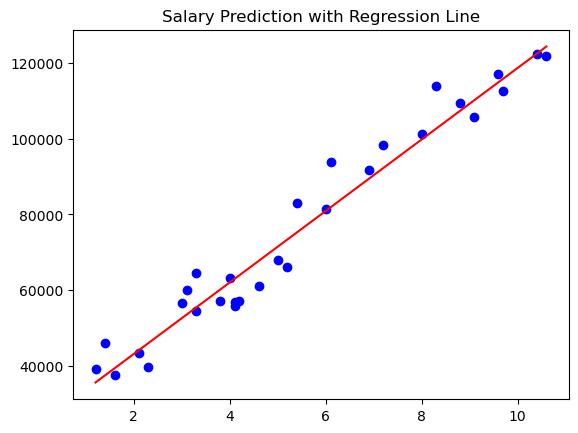

In [35]:
# Plot regression line
plt.scatter(X, y, color='blue')
plt.plot(X, regressor.predict(X), color='red')
plt.title("Salary Prediction with Regression Line")
plt.show()

In [37]:
# Manual Gradient Descent
X_exp = salary['YearsExperience'].values
Y_sal = salary['Salary'].values
m, b = 0, 0
lr = 0.01
epochs = 1000
costs = []


for _ in range(epochs):
    y_pred = m*X_exp + b
    error = Y_sal - y_pred
    cost = (error**2).mean()
    costs.append(cost)
    m_grad = -(2/len(X_exp)) * sum(X_exp * error)
    b_grad = -(2/len(X_exp)) * sum(error)
    m -= lr * m_grad
    b -= lr * b_grad


print("\n--- Gradient Descent (Salary) ---")
print(f"Slope: {m}, Intercept: {b}")


--- Gradient Descent (Salary) ---
Slope: 9504.801321957242, Intercept: 24474.557566113308


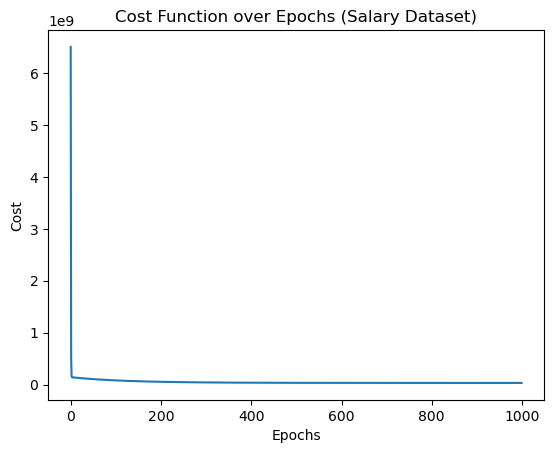

In [38]:
# Cost plot
plt.plot(range(epochs), costs)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Cost Function over Epochs (Salary Dataset)")
plt.show()